In [82]:
import pandas as pd
import numpy as np

In [83]:
df = pd.read_csv(r"D:\Downloads\documents\Smart-Food-Wastage-Prediction\food_wastage_cleaned.csv")

In [84]:
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,meat,310.0,corporate,450.0,refrigerated,Regular,All Seasons,Buffet,Urban,Low,25.0
1,meat,400.0,birthday,500.0,room temperature,Regular,Winter,Buffet,Suburban,High,40.0
2,vegetables,302.0,birthday,400.0,refrigerated,Regular,Summer,Buffet,Suburban,Low,27.0
3,meat,491.0,birthday,497.0,refrigerated,Regular,All Seasons,Finger Food,Rural,High,32.0
4,meat,300.0,corporate,400.0,refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25.0


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Type of Food           1723 non-null   str    
 1   Number of Guests       1723 non-null   float64
 2   Event Type             1723 non-null   str    
 3   Quantity of Food       1723 non-null   float64
 4   Storage Conditions     1723 non-null   str    
 5   Purchase History       1723 non-null   str    
 6   Seasonality            1723 non-null   str    
 7   Preparation Method     1723 non-null   str    
 8   Geographical Location  1723 non-null   str    
 9   Pricing                1723 non-null   str    
 10  Wastage Food Amount    1723 non-null   float64
dtypes: float64(3), str(8)
memory usage: 269.8 KB


## Encoding

In [86]:
from sklearn.preprocessing import LabelEncoder

In [87]:
le = LabelEncoder()

In [88]:
categorical_columns = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Purchase History',
    'Seasonality',
    'Preparation Method',
    'Geographical Location',
    'Pricing'
]

In [89]:
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,3,310.0,1,450.0,0,1,0,0,2,1,25.0
1,3,400.0,0,500.0,1,1,2,0,1,0,40.0
2,4,302.0,0,400.0,0,1,1,0,1,1,27.0
3,3,491.0,0,497.0,0,1,0,1,0,0,32.0
4,3,300.0,1,400.0,0,1,2,1,2,2,25.0


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Type of Food           1723 non-null   int64  
 1   Number of Guests       1723 non-null   float64
 2   Event Type             1723 non-null   int64  
 3   Quantity of Food       1723 non-null   float64
 4   Storage Conditions     1723 non-null   int64  
 5   Purchase History       1723 non-null   int64  
 6   Seasonality            1723 non-null   int64  
 7   Preparation Method     1723 non-null   int64  
 8   Geographical Location  1723 non-null   int64  
 9   Pricing                1723 non-null   int64  
 10  Wastage Food Amount    1723 non-null   float64
dtypes: float64(3), int64(8)
memory usage: 148.2 KB


## save the encoding mapping for streamlit later on.

In [91]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported for pd.read_csv

categorical_columns = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Purchase History',
    'Seasonality',
    'Preparation Method',
    'Geographical Location',
    'Pricing'
]

encoders = {}

# Load a fresh, unencoded copy of the DataFrame to fit the LabelEncoders.
# This ensures that the encoders are fitted on the original string values
# without altering the 'df' that has already been transformed for model training.
df_raw = pd.read_csv(r"D:\Downloads\documents\Smart-Food-Wastage-Prediction\food_wastage_cleaned.csv")


for col in categorical_columns:
    le = LabelEncoder()
    # Fit the encoder using the raw (string) categorical data
    le.fit(df_raw[col])
    # Store the fitted encoder in the dictionary
    encoders[col] = le

# Note: The main 'df' used for the model is already encoded by cell 77a53454-976e-4aff-861b-de82bb0acdc8.
# This cell only serves to create and store the LabelEncoder objects for later use (e.g., Streamlit).
# Therefore, we do not perform df[col] = le.fit_transform(df_raw[col]) here to avoid re-encoding or overwriting the main df.

In [92]:
for col in categorical_columns:
    print(f"\n{col}")
    print(dict(zip(
        encoders[col].classes_,
        encoders[col].transform(encoders[col].classes_)
    )))


Type of Food
{'baked goods': np.int64(0), 'dairy products': np.int64(1), 'fruits': np.int64(2), 'meat': np.int64(3), 'vegetables': np.int64(4)}

Event Type
{'birthday': np.int64(0), 'corporate': np.int64(1), 'social gathering': np.int64(2), 'wedding': np.int64(3)}

Storage Conditions
{'refrigerated': np.int64(0), 'room temperature': np.int64(1)}

Purchase History
{'Occasional': np.int64(0), 'Regular': np.int64(1)}

Seasonality
{'All Seasons': np.int64(0), 'Summer': np.int64(1), 'Winter': np.int64(2)}

Preparation Method
{'Buffet': np.int64(0), 'Finger Food': np.int64(1), 'Sit-down Dinner': np.int64(2)}

Geographical Location
{'Rural': np.int64(0), 'Suburban': np.int64(1), 'Urban': np.int64(2)}

Pricing
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}


## Define Features & Target

In [93]:
X = df.drop('Wastage Food Amount', axis=1)

In [94]:
y = df['Wastage Food Amount']

In [95]:
print(X.shape)
print(y.shape)

(1723, 10)
(1723,)


## Scaling

In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()

In [98]:
X_scaled = scaler.fit_transform(X)

In [99]:
X_scaled

array([[ 0.88069135, -0.16729727, -0.50757832, ..., -1.74954535,
         1.25289056,  0.01341626],
       [ 0.88069135,  0.96498224, -1.43598325, ..., -1.74954535,
        -0.12472937, -1.14239485],
       [ 1.61910069, -0.26794434, -1.43598325, ..., -1.74954535,
        -0.12472937,  0.01341626],
       ...,
       [ 0.88069135, -0.16729727,  1.34923155, ...,  0.99337243,
        -0.12472937,  0.01341626],
       [-1.33453668,  5.55700473, -0.50757832, ...,  0.99337243,
        -0.12472937,  0.01341626],
       [-0.59612733, -0.16729727, -0.50757832, ...,  0.99337243,
        -0.12472937,  0.01341626]], shape=(1723, 10))

## Train Test Split

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [102]:
print(X_train.shape)
print(X_test.shape)

(1378, 10)
(345, 10)


## Train First Model (Linear Regression)

In [103]:
from sklearn.linear_model import LinearRegression

In [104]:
lr_model = LinearRegression()

In [105]:
# Train Model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.49, 2.62,-0.23,..., 1.09, 0.38,-5.5 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,28.47
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[51.42,49.17,39.78,...,31.17,26.06,20.29]"


In [106]:
# Prediction
y_pred_lr = lr_model.predict(X_test)
y_pred_lr

array([21.8418618 , 29.11747797, 21.59070458, 20.01985613, 32.11155765,
       32.60475132, 26.09504024, 24.89867301, 37.41974819, 20.06481151,
       17.96644338, 17.91218702, 21.96210202, 23.60780933, 26.67692314,
       34.86671142, 16.61133035, 40.38363643, 40.84171723, 31.82879687,
       40.13614677, 17.77769084, 19.71726572, 28.32650609, 33.59673543,
       21.18785539, 32.72484142, 24.76967924, 19.25837946, 25.48231988,
       33.74831048, 38.05319705, 27.7089461 , 26.1943879 , 16.3137737 ,
       16.34661038, 24.2272344 , 27.85587319, 22.52716816, 33.70525665,
       36.75568153, 44.29097686, 23.13399165, 19.92112029, 39.10584179,
       24.47459708, 34.03506311, 33.40544727, 34.2685285 , 34.51180761,
       24.3299537 , 18.2861549 , 25.73447701, 35.67265101, 34.94584488,
       18.44593854, 23.32808615, 24.07806891, 33.25833712, 25.69667169,
       23.8028917 , 22.28897197, 20.16625082, 25.12297496, 31.61420038,
       30.94785747, 37.17929086, 27.64348534, 30.75364924, 36.83

## Evaluate Model

In [107]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [108]:
# check performance
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.58115500407028
MSE: 50.215660416932785
RMSE: 7.086300897995567
R2 Score: 0.4899620072331805


In [109]:
# saving results
results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'MSE': [mse],
    'RMSE': [rmse],
    'R2 Score': [r2]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.21566,7.086301,0.489962


## Model 2 — Decision Tree Regressor

In [110]:
from sklearn.tree import DecisionTreeRegressor

In [111]:
dt_model = DecisionTreeRegressor(random_state=42)

In [112]:
# Train model
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [113]:
# Prediction
y_pred_dt = dt_model.predict(X_test)

In [114]:
# Evaluate Model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 2.734782608695652
MSE: 28.509420289855072
RMSE: 5.339421344102287
R2 Score: 0.7104312204827617


In [115]:
new_result = pd.DataFrame({
    'Model': ['Decision Tree'],
    'MAE': [mae_dt],
    'MSE': [mse_dt],
    'RMSE': [rmse_dt],
    'R2 Score': [r2_dt]
})

results = pd.concat([results, new_result], ignore_index=True)

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.21566,7.086301,0.489962
1,Decision Tree,2.734783,28.50942,5.339421,0.710431


## Model 3 — Random Forest Regressor ⭐

In [116]:
from sklearn.ensemble import RandomForestRegressor

In [117]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [118]:
# Train
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [119]:
# Prediction
y_pred_rf = rf_model.predict(X_test)

In [120]:
# Evaluate Model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 2.3988045883263274
MSE: 15.68172418716524
RMSE: 3.9600156801665873
R2 Score: 0.8407214988086144


In [121]:
new_result = pd.DataFrame({
    'Model': ['Random Forest'],
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'RMSE': [rmse_rf],
    'R2 Score': [r2_rf]
})

results = pd.concat([results, new_result], ignore_index=True)

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.215660,7.086301,0.489962
1,Decision Tree,2.734783,28.509420,5.339421,0.710431
2,Random Forest,2.398805,15.681724,3.960016,0.840721


## Compare Models Properly

In [122]:
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.581155,50.215660,7.086301,0.489962
1,Decision Tree,2.734783,28.509420,5.339421,0.710431
2,Random Forest,2.398805,15.681724,3.960016,0.840721


In [123]:
results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,2.398805,15.681724,3.960016,0.840721
1,Decision Tree,2.734783,28.509420,5.339421,0.710431
0,Linear Regression,5.581155,50.215660,7.086301,0.489962


## Visualization of Model Comparison ⭐

In [124]:
import matplotlib.pyplot as plt

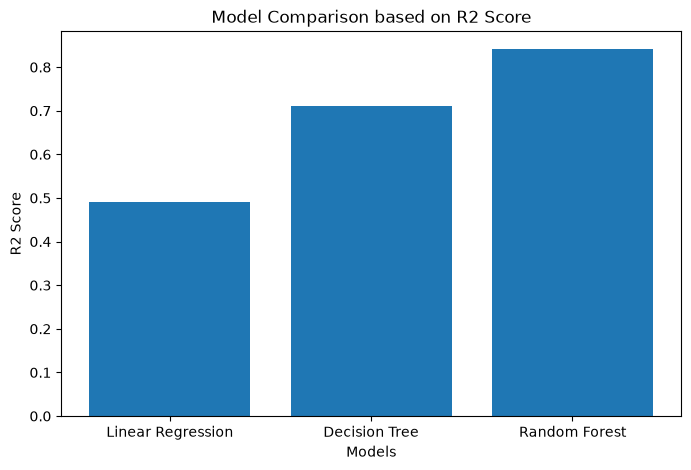

In [125]:
# R² Score Comparison
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['R2 Score'])

plt.title("Model Comparison based on R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

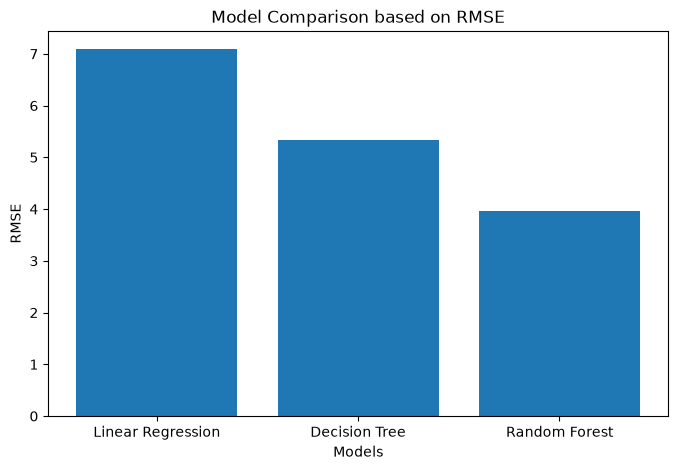

In [126]:
# RMSE comparison
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['RMSE'])

plt.title("Model Comparison based on RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

## Test One Prediction

In [127]:
sample_input = pd.DataFrame([{
    'Type of Food': 3,
    'Number of Guests': 380,
    'Event Type': 0,
    'Quantity of Food': 500,
    'Storage Conditions': 0,
    'Purchase History': 1,
    'Seasonality': 2,
    'Preparation Method': 2,
    'Geographical Location': 1,
    'Pricing': 0
}])

In [128]:
sample_input_scaled = scaler.transform(sample_input)

In [129]:
prediction = rf_model.predict(sample_input_scaled)

print("Predicted Food Wastage:", prediction[0])

Predicted Food Wastage: 35.25


## Feature Importance

In [130]:
prediction = rf_model.predict(sample_input_scaled)

print("Predicted Food Wastage:", prediction[0])

Predicted Food Wastage: 35.25


In [131]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Type of Food,0.027266
1,Number of Guests,0.174221
2,Event Type,0.023186
3,Quantity of Food,0.102179
4,Storage Conditions,0.008507
5,Purchase History,0.005364
6,Seasonality,0.017370
7,Preparation Method,0.047117
8,Geographical Location,0.018994
9,Pricing,0.575795


In [132]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
9,Pricing,0.575795
1,Number of Guests,0.174221
3,Quantity of Food,0.102179
7,Preparation Method,0.047117
0,Type of Food,0.027266
2,Event Type,0.023186
8,Geographical Location,0.018994
6,Seasonality,0.017370
4,Storage Conditions,0.008507
5,Purchase History,0.005364


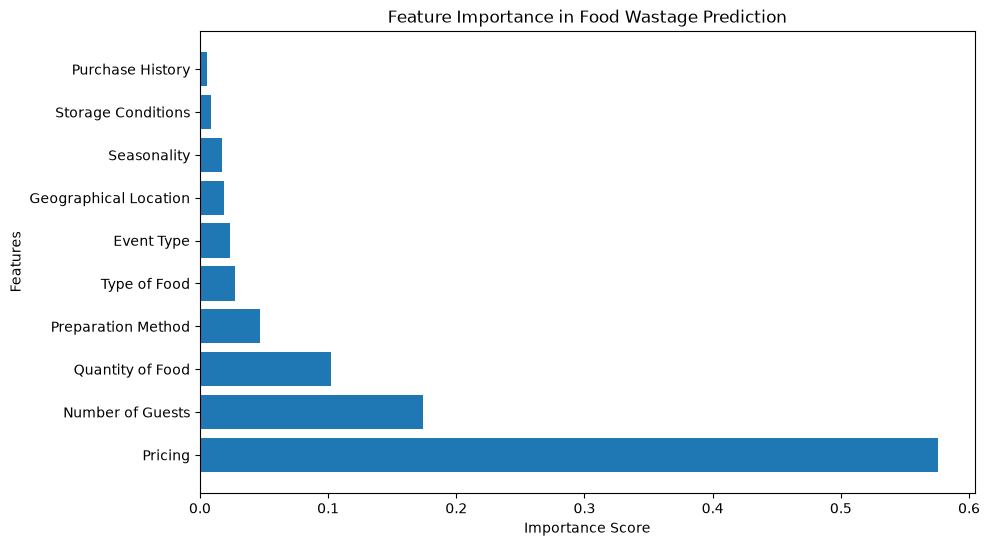

In [133]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance in Food Wastage Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Save Best Model ⭐

In [134]:
import joblib

In [141]:
# save model
joblib.dump(rf_model, 'food_wastage_model.pkl')

['food_wastage_model.pkl']

In [142]:
# save scalar
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [143]:
# save Encoders
joblib.dump(encoders, 'label_encoders.pkl')

['label_encoders.pkl']